<a href="https://colab.research.google.com/github/r-borgess/enucompi2025-deep-learning-imagens-faciais/blob/main/enucompi2025_deep_learning_imagens_faciais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import random
from tqdm.notebook import tqdm

# Configurando visualizações
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (12, 8)

# Importando TensorFlow e Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNet, DenseNet201
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Bibliotecas para visualização e interpretabilidade
from sklearn.metrics import confusion_matrix, classification_report
import cv2


In [ ]:
# Verificando se a GPU está disponível e configurando-a
print("TensorFlow versão:", tf.__version__)
print("Keras versão:", keras.__version__)
print("GPU disponível: ", tf.test.is_gpu_available())
print("Dispositivos disponíveis:")
print(tf.config.list_physical_devices())

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


TensorFlow versão: 2.18.0
Keras versão: 3.8.0
GPU disponível:  True
Dispositivos disponíveis:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Se houver GPU, vamos configurá-la para crescimento de memória conforme necessário
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Configurando para uso dinâmico de memória
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs com alocação dinâmica de memória: {len(gpus)}")
    except RuntimeError as e:
        print(f"Erro na configuração da GPU: {e}")

GPUs com alocação dinâmica de memória: 1


In [ ]:
# Montando o Google Drive para acessar os dados
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Definindo o caminho para a pasta de dados
# Você precisará ajustar este caminho para o local correto no seu Drive
BASE_PATH = '/content/drive/MyDrive/AutismDataset'

# Definindo caminhos para os diferentes conjuntos de dados
CONSOLIDATED_PATH = os.path.join(BASE_PATH, 'consolidated')
TRAIN_PATH = os.path.join(BASE_PATH, 'train')
VALID_PATH = os.path.join(BASE_PATH, 'valid')
TEST_PATH = os.path.join(BASE_PATH, 'test')

In [ ]:
# Verificando se os caminhos estão corretos
try:
    print(f"Estrutura do dataset de Autismo:")
    print(f"- Diretório base: {BASE_PATH}")

    # Verificando conjunto consolidado
    if os.path.exists(CONSOLIDATED_PATH):
        autistic_consolidated = os.path.join(CONSOLIDATED_PATH, 'Autistic')
        non_autistic_consolidated = os.path.join(CONSOLIDATED_PATH, 'Non_Autistic')
        autistic_count = len(os.listdir(autistic_consolidated))
        non_autistic_count = len(os.listdir(non_autistic_consolidated))
        print(f"- Conjunto consolidado: {autistic_count} imagens Autistic, {non_autistic_count} imagens Non_Autistic")

    # Verificando conjunto de treinamento
    if os.path.exists(TRAIN_PATH):
        train_files = os.listdir(TRAIN_PATH)
        autistic_train = len([f for f in train_files if 'Autistic.' in f])
        non_autistic_train = len([f for f in train_files if 'Non_autistic.' in f])
        print(f"- Conjunto de treinamento: {autistic_train} imagens Autistic, {non_autistic_train} imagens Non_Autistic")

    # Verificando conjunto de validação
    if os.path.exists(VALID_PATH):
        autistic_valid = os.path.join(VALID_PATH, 'Autistic')
        non_autistic_valid = os.path.join(VALID_PATH, 'Non_Autistic')
        autistic_valid_count = len(os.listdir(autistic_valid))
        non_autistic_valid_count = len(os.listdir(non_autistic_valid))
        print(f"- Conjunto de validação: {autistic_valid_count} imagens Autistic, {non_autistic_valid_count} imagens Non_Autistic")

    # Verificando conjunto de teste
    if os.path.exists(TEST_PATH):
        test_files = os.listdir(TEST_PATH)
        autistic_test = len([f for f in test_files if 'Autistic.' in f])
        non_autistic_test = len([f for f in test_files if 'Non_autistic.' in f])
        print(f"- Conjunto de teste: {autistic_test} imagens Autistic, {non_autistic_test} imagens Non_Autistic")

    print("\nEstrutura de diretórios verificada com sucesso!")

    # Mostrar algumas informações sobre as imagens
    print("\nObtendo informações sobre as imagens...")

    # Vamos verificar o formato de uma imagem de exemplo
    sample_image_path = os.path.join(TRAIN_PATH, os.listdir(TRAIN_PATH)[0])
    sample_image = cv2.imread(sample_image_path)
    if sample_image is not None:
        print(f"Dimensões da imagem de exemplo: {sample_image.shape}")
        print(f"Tipo de dados da imagem: {sample_image.dtype}")
except Exception as e:
    print(f"ERRO ao acessar os dados: {e}")
    print("Por favor, verifique se o caminho está correto ou se você deu permissão de acesso ao Colab.")

Estrutura do dataset de Autismo:
- Diretório base: /content/drive/MyDrive/AutismDataset
- Conjunto consolidado: 1470 imagens Autistic, 1470 imagens Non_Autistic
- Conjunto de treinamento: 2540 imagens Autistic, 0 imagens Non_Autistic
- Conjunto de validação: 50 imagens Autistic, 50 imagens Non_Autistic
- Conjunto de teste: 300 imagens Autistic, 0 imagens Non_Autistic

Estrutura de diretórios verificada com sucesso!

Obtendo informações sobre as imagens...
Dimensões da imagem de exemplo: (384, 373, 3)
Tipo de dados da imagem: uint8


In [ ]:
# Definindo sementes para reprodutibilidade
def set_seed(seed=42):
    """Define sementes para reprodutibilidade"""
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Sementes definidas com o valor: {seed}")

In [ ]:
set_seed(42)

Sementes definidas com o valor: 42


In [ ]:
# Função para exibir uma amostra de imagens do dataset
def visualize_sample_images(dataset_path, num_samples=3, class_names=None):
    """
    Visualiza uma amostra de imagens do dataset

    Args:
        dataset_path: Caminho para o conjunto de dados
        num_samples: Número de amostras a serem exibidas por classe
        class_names: Lista de nomes das classes (se None, serão inferidos)
    """
    plt.figure(figsize=(15, 4 * (num_samples if class_names else 2)))

    # Verificamos a estrutura do diretório
    is_directory_structure = False
    try:
        # Verifica se o primeiro item no diretório é também um diretório (estrutura de pastas)
        first_item = os.listdir(dataset_path)[0]
        is_directory_structure = os.path.isdir(os.path.join(dataset_path, first_item))
    except (IndexError, FileNotFoundError) as e:
        print(f"Erro ao verificar a estrutura do diretório: {e}")
        return

    # Inicializamos o dicionário para armazenar as imagens por classe
    images_by_class = {}

    # Determinamos as classes e as imagens correspondentes com base na estrutura
    if class_names is None:
        if is_directory_structure:
            # Formato: dataset/class/image.jpg (como em consolidated e valid)
            class_names = sorted([d for d in os.listdir(dataset_path)
                                if os.path.isdir(os.path.join(dataset_path, d))])
        else:
            # Formato: dataset/class.image.jpg (como em train e test)
            all_files = os.listdir(dataset_path)
            unique_prefixes = set()

            for file in all_files:
                if '.' in file:  # Certifica-se de que o arquivo tem uma extensão
                    prefix = file.split('.')[0]
                    unique_prefixes.add(prefix)

            class_names = sorted(list(unique_prefixes))

    print(f"Classes encontradas: {class_names}")

    # Coletamos as imagens para cada classe
    for class_name in class_names:
        if is_directory_structure:
            # Estrutura dataset/class/image.jpg
            class_dir = os.path.join(dataset_path, class_name)
            if os.path.exists(class_dir) and os.path.isdir(class_dir):
                images_by_class[class_name] = [f for f in os.listdir(class_dir)
                                              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        else:
            # Estrutura dataset/class.image.jpg
            images_by_class[class_name] = [f for f in os.listdir(dataset_path)
                                         if f.startswith(f"{class_name}.") or
                                            f.startswith(f"{class_name}_")]

    # Verificamos se temos imagens para exibir
    if not any(images_by_class.values()):
        print(f"Nenhuma imagem encontrada em {dataset_path} para as classes {class_names}")
        return

    # Exibimos imagens para cada classe
    total_classes = sum(1 for c in class_names if c in images_by_class and images_by_class[c])

    plot_idx = 1
    for i, class_name in enumerate(class_names):
        if class_name not in images_by_class or not images_by_class[class_name]:
            print(f"Nenhuma imagem encontrada para a classe '{class_name}'")
            continue

        # Selecionamos amostras aleatórias
        available_images = images_by_class[class_name]
        if len(available_images) < num_samples:
            print(f"Aviso: Apenas {len(available_images)} imagens disponíveis para '{class_name}', "
                  f"menos que as {num_samples} solicitadas")

        samples = random.sample(available_images, min(num_samples, len(available_images)))

        # Exibimos cada amostra
        for img_name in samples:
            plt.subplot(total_classes, num_samples, plot_idx)

            # Determinamos o caminho da imagem com base na estrutura
            if is_directory_structure:
                img_path = os.path.join(dataset_path, class_name, img_name)
            else:
                img_path = os.path.join(dataset_path, img_name)

            # Lemos e exibimos a imagem
            try:
                img = cv2.imread(img_path)
                if img is None:
                    print(f"Erro ao ler a imagem: {img_path}")
                    plt.text(0.5, 0.5, "Erro ao carregar a imagem",
                             ha='center', va='center', transform=plt.gca().transAxes)
                else:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    plt.imshow(img)
                    plt.title(f"{class_name}: {os.path.basename(img_path)}")
            except Exception as e:
                print(f"Erro ao processar a imagem {img_path}: {e}")
                plt.text(0.5, 0.5, "Erro", ha='center', va='center', transform=plt.gca().transAxes)

            plt.axis("off")
            plot_idx += 1

    plt.tight_layout()
    plt.suptitle(f"Exemplo de imagens do conjunto: {os.path.basename(dataset_path)}",
                 fontsize=16, y=1.02)
    plt.show()

Classes encontradas: ['Autistic', 'Non_Autistic']


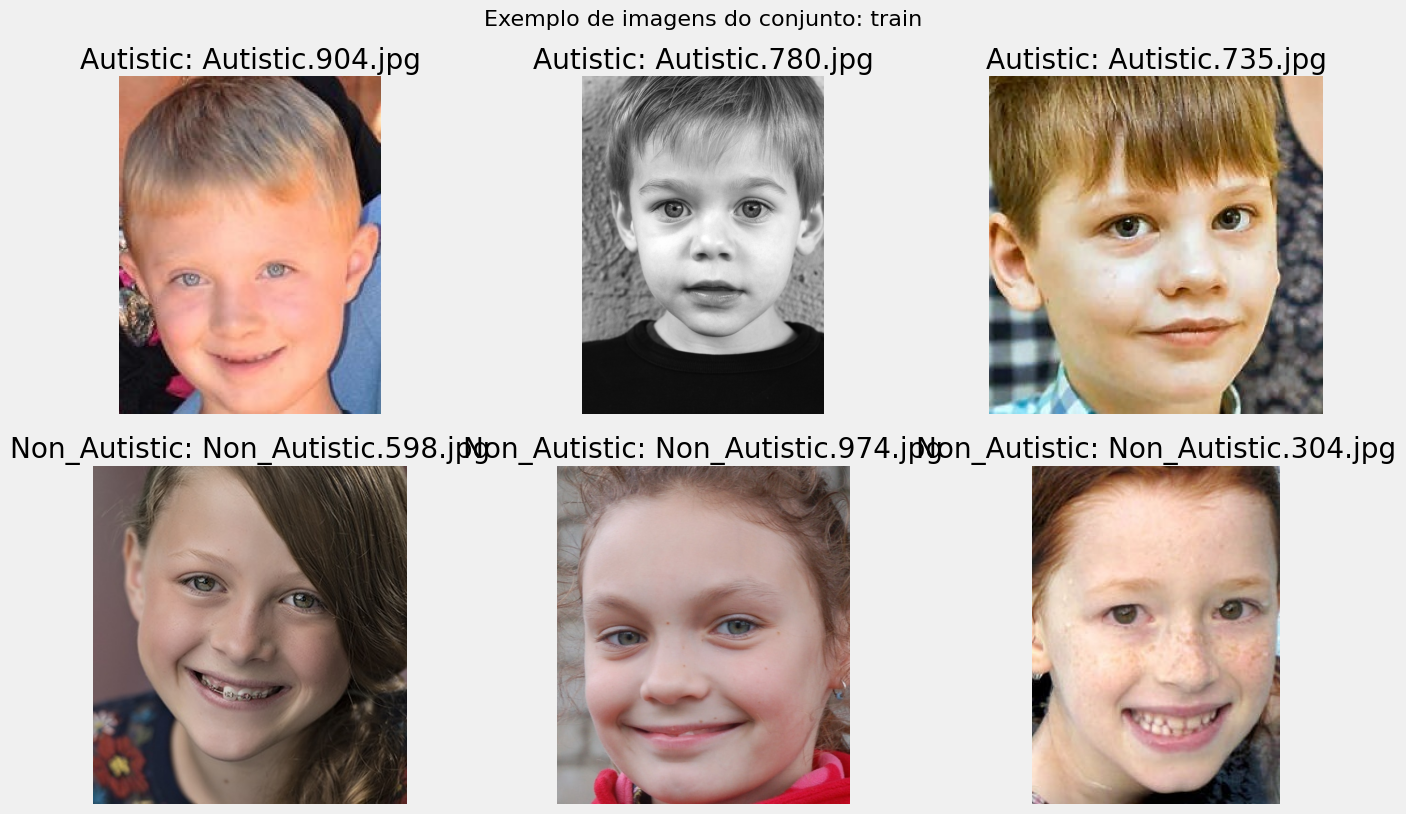

In [ ]:
visualize_sample_images(TRAIN_PATH, num_samples=3)
#visualize_sample_images(VALID_PATH, num_samples=3)

In [ ]:
# Função para contar a distribuição de imagens por classe
def count_images_per_class(dataset_path):
    """
    Conta o número de imagens por classe em um conjunto de dados

    Args:
        dataset_path: Caminho para o conjunto de dados

    Returns:
        Um dicionário com a contagem de imagens por classe
    """
    # Verificamos a estrutura do diretório
    is_directory_structure = False
    try:
        # Verifica se o primeiro item no diretório é também um diretório
        first_item = os.listdir(dataset_path)[0]
        is_directory_structure = os.path.isdir(os.path.join(dataset_path, first_item))
    except (IndexError, FileNotFoundError) as e:
        print(f"Erro ao verificar a estrutura do diretório: {e}")
        return {}

    # Contagem de imagens por classe
    class_counts = {}

    if is_directory_structure:
        # Formato: dataset/class/image.jpg (como em consolidated e valid)
        for class_name in os.listdir(dataset_path):
            class_dir = os.path.join(dataset_path, class_name)
            if os.path.isdir(class_dir):
                image_files = [f for f in os.listdir(class_dir)
                              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                class_counts[class_name] = len(image_files)
    else:
        # Formato: dataset/class.image.jpg (como em train e test)
        for filename in os.listdir(dataset_path):
            if '.' in filename and filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                class_name = filename.split('.')[0]
                class_counts[class_name] = class_counts.get(class_name, 0) + 1

    return class_counts

# Função para visualizar a distribuição de classes
def visualize_class_distribution(base_path, datasets=['consolidated', 'train', 'valid', 'test']):
    """
    Visualiza a distribuição de classes em diferentes conjuntos de dados

    Args:
        base_path: Caminho base para os conjuntos de dados
        datasets: Lista de nomes dos conjuntos de dados a serem analisados
    """
    # Configuração do estilo do gráfico
    plt.style.use('fivethirtyeight')

    # Criação da figura com subplots
    fig, axes = plt.subplots(len(datasets), 1, figsize=(12, 4 * len(datasets)))

    # Se tivermos apenas um dataset, transformamos axes em uma lista para evitar erros
    if len(datasets) == 1:
        axes = [axes]

    # Para cada conjunto de dados
    for i, dataset_name in enumerate(datasets):
        dataset_path = os.path.join(base_path, dataset_name)

        if not os.path.exists(dataset_path):
            print(f"Conjunto de dados '{dataset_name}' não encontrado em {dataset_path}")
            continue

        # Contagem das imagens por classe
        class_counts = count_images_per_class(dataset_path)

        if not class_counts:
            print(f"Nenhuma classe encontrada em {dataset_path}")
            continue

        # Ordenamos as classes para consistência
        sorted_classes = sorted(class_counts.keys())
        counts = [class_counts[cls] for cls in sorted_classes]

        # Criação do gráfico de barras
        ax = axes[i]
        bars = ax.bar(sorted_classes, counts, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(sorted_classes)])

        # Adicionamos os números em cima das barras
        for bar, count in zip(bars, counts):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 5,
                   f'{count}', ha='center', va='bottom', fontweight='bold')

        # Calculamos o total e as porcentagens
        total = sum(counts)
        for j, (bar, count) in enumerate(zip(bars, counts)):
            percentage = 100 * count / total
            ax.text(bar.get_x() + bar.get_width()/2., height/2,
                   f'{percentage:.1f}%', ha='center', va='center',
                   color='white', fontweight='bold')

        # Configuração do título e eixos
        ax.set_title(f'Distribuição de Classes - {dataset_name.capitalize()}', fontsize=16)
        ax.set_ylabel('Número de Imagens', fontsize=14)
        ax.set_ylim(0, max(counts) * 1.2)  # Damos espaço para os rótulos

        # Personalizamos os eixos para melhor legibilidade
        for tick in ax.get_xticklabels():
            tick.set_rotation(0)
            tick.set_fontsize(12)

        # Adicionamos o total no gráfico
        ax.text(0.98, 0.95, f'Total: {total} imagens',
                transform=ax.transAxes, ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f0f0', alpha=0.7))

    # Ajustamos o layout
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4)

    # Exibimos a figura (sem retorná-la)
    plt.show()

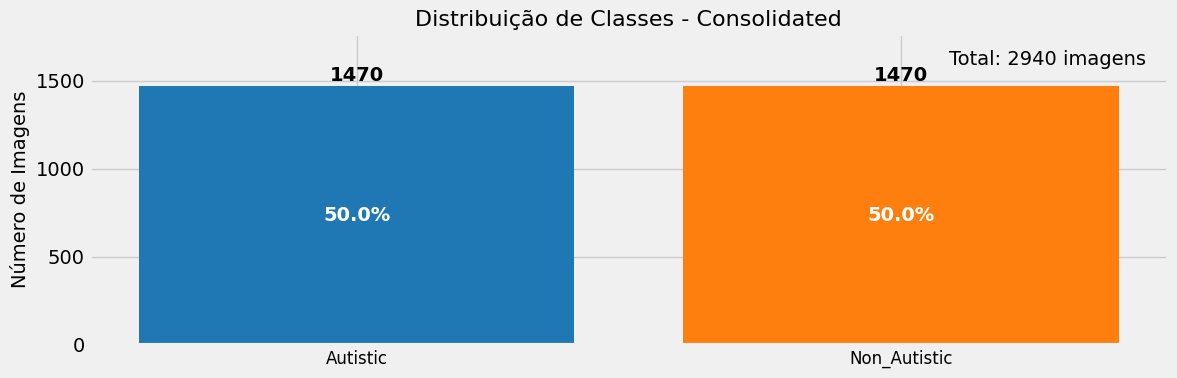

In [ ]:
visualize_class_distribution(BASE_PATH, datasets=['consolidated'])